# 6.2 The S$_N$2 Reaction by Nudged Elastic Band

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume VI — Reactions and Free Energy",
    number="6.2",
    title="The Sₙ2 Reaction by Nudged Elastic Band",
    blurb="Finding the path a reaction takes, not just its endpoints: the nudged "
    "elastic band relaxes a chain of images into the minimum-energy path for chloride "
    "exchange on chloromethane, and the top of that path is the activation barrier.",
    difficulty="intermediate",
    estimate="75–100 min",
    source="FS 2023 · Lecture 11 (nudged elastic band and free energy)",
)

<ECP header: 2832 chars of HTML>

## Notebook overview

The textbook **Sₙ2 reaction**: a chloride ion attacks chloromethane from behind,
the three hydrogens flip through like an umbrella in the wind, and a chloride leaves
from the front, $\mathrm{Cl^- + CH_3Cl \to ClCH_3 + Cl^-}$. Knowing the reactant and
product is not enough; we want the **path** between them and the **barrier** at its
crest. The **nudged elastic band** (NEB) finds both: it strings a chain of replicas
of the system between the two endpoints, connects them with springs, and relaxes the
chain onto the minimum-energy path.

We take the course's NEB calculation in CP2K and its committed output: the optimised
reactant and product geometries, and the energy of every image at every iteration of
the band optimisation. We render the two endpoints and the umbrella inversion between
them, read the converged band to plot the energy profile and extract the activation
barrier, and watch the band converge onto the minimum-energy path over the
optimisation.

> **Provenance.** This notebook develops **Lecture 11** of the course (nudged elastic
> band and free-energy calculations), an exercise **designed by the author
> (Raymond Amador)**. The endpoint structures (`a.xyz`, `b.xyz`) and
> the band energies (`ch3cl-neb-1.ener`) are the course's own committed CP2K results.
> The full course credit is in the footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: a symmetric reaction must give a symmetric path, the transition state sits at
> the top, the band must converge. A ✗ flags a mismatch; a ✓ is strong evidence, not
> proof.

> **Scope.** Energies are the committed CP2K totals (Hartree, converted to kcal/mol);
> we analyse the band rather than rerun it. For the method see the nudged elastic band
> {cite}`henkelman2000`.

## Theory in brief

### The minimum-energy path

A reaction follows the **minimum-energy path** on the potential surface: the lowest
ridge crossing from the reactant valley to the product valley. Its highest point is
the **transition state**, and the energy there above the reactant is the activation
barrier {eq}`eq-barrier-neb`,

```{math}
:label: eq-barrier-neb
\Delta E^{\ddagger} = E_{\rm TS} - E_{\rm reactant}.
```

### Nudged elastic band

The NEB discretises the path into a chain of **images**, copies of the system
interpolated between the fixed endpoints. Adjacent images are joined by **springs** to
keep them spread out, and each image is relaxed using only the force component
*perpendicular* to the path (from the true potential) plus the spring force *along*
the path. This "nudging" stops the images sliding into the endpoints or cutting the
corner, so the converged chain traces the minimum-energy path, and its peak is the
barrier. For the symmetric Sₙ2 exchange the path must be symmetric, with the
transition state, the trigonal-bipyramidal $\mathrm{[Cl\cdots CH_3\cdots Cl]^-}$, at
its midpoint.

---
## Setup

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
HARTREE_KCAL = 627.503
CPK = {"H": "#d9d9d9", "C": "#303030", "Cl": "#3da639"}
RADIUS = {"H": 0.31, "C": 0.76, "Cl": 1.02}


def data_file(name):
    """Locate a shipped data file, from the repo root (CI) or the notebook dir (Colab).

    Parameters
    ----------
    name : str
        File name (or relative path) under a ``data`` directory.

    Returns
    -------
    str
        The first existing path found.

    Raises
    ------
    FileNotFoundError
        If the file is not found under any candidate base.
    """
    for base in ("data", os.path.join("notebooks", "06-reactions-free-energy", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_xyz(name):
    """Read an .xyz file.

    Parameters
    ----------
    name : str
        File name (coordinates in Å).

    Returns
    -------
    tuple
        ``(elements, coords)``: a list of element symbols and an (N, 3)
        coordinate array in Å.
    """
    lines = open(data_file(name)).read().splitlines()
    n = int(lines[0].split()[0])
    els = [ln.split()[0] for ln in lines[2:2 + n]]
    xyz = np.array([[float(v) for v in ln.split()[1:4]] for ln in lines[2:2 + n]])
    return els, xyz


def draw_molecule(ax, els, xyz, title=""):
    """Draw a molecule as a ball-and-stick figure on a 3-D axis.

    Parameters
    ----------
    ax : mpl_toolkits.mplot3d.axes3d.Axes3D
        The 3-D axis to draw on.
    els : list of str
        Element symbols.
    xyz : numpy.ndarray
        Coordinates, shape (N, 3), in Å.
    title : str, optional
        Axis title.

    Notes
    -----
    A bond is drawn between two atoms within a generous multiple of the sum of
    their covalent radii, so loosely-placed input geometries still show bonds.
    """
    for i in range(len(els)):
        for j in range(i + 1, len(els)):
            d = np.linalg.norm(xyz[i] - xyz[j])
            if d < 1.3 * (RADIUS.get(els[i], 0.7) + RADIUS.get(els[j], 0.7)):
                ax.plot(*zip(xyz[i], xyz[j]), color=SOFT, lw=2.5, alpha=0.7)
    for el, r in zip(els, xyz):
        ax.scatter(*r, s=380 * RADIUS.get(el, 0.7), color=CPK.get(el, "#888"),
                   edgecolors="white", depthshade=True)
    ax.set(xticks=[], yticks=[], zticks=[], title=title)
    ax.set_box_aspect((1, 1, 1))

## Exercise 1 — The reactant and product

The two endpoints are the same molecule mirror-imaged: in the reactant the carbon is
bonded to one chlorine with the other chloride loosely approaching from behind; in the
product the bonding has swapped. We render both. The hallmark of the Sₙ2 mechanism is
that the three hydrogens **invert** between them, like an umbrella turning inside out,
as the reaction passes through a planar $\mathrm{CH_3}$ transition state.

**Part a)** Render the reactant and product. **Part b)** Confirm the C–Cl bonding
swaps between the two (the chlorine that is bonded becomes the one that leaves).

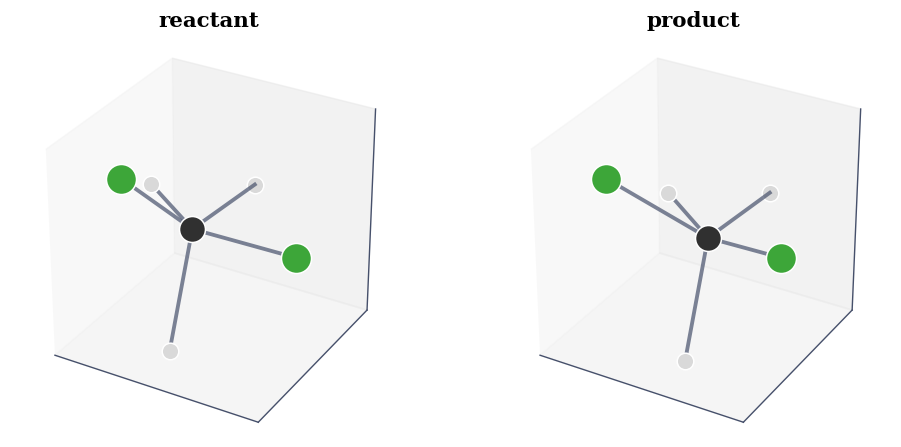

reactant C–Cl distances: 1.76, 2.26 Å;  product: 1.46, 2.26 Å


In [3]:
# (solution hidden on the public site)


### Validation 1 — a short and a long C–Cl bond at each end

Each endpoint has one bonded chlorine (~1.8 Å) and one departing/attacking chlorine
much farther away: the asymmetry that the reaction reverses.

In [4]:
validate.check(
    near_r < 2.2 < far_r and near_p < 2.2 < far_p,
    "each endpoint has one bonded and one distant chlorine",
    f"reactant {near_r:.2f}/{far_r:.2f} Å, product {near_p:.2f}/{far_p:.2f} Å",
)

✓  each endpoint has one bonded and one distant chlorine   [reactant 1.76/2.26 Å, product 1.46/2.26 Å]


True

## Exercise 2 — The minimum-energy path and the barrier

The band optimisation writes the energy of every image at every step to a `.ener`
file; its last line is the converged path. We read the ten image energies, measure
each relative to the endpoints, and plot the profile against the reaction coordinate
(the cumulative distance along the band, Assignment 4). The result is a single
symmetric barrier; its height is the activation energy of the exchange (Assignment 2).

**Part a)** Read the converged band and plot the energy profile. **Part b)** Extract
the activation barrier and confirm the path is symmetric.

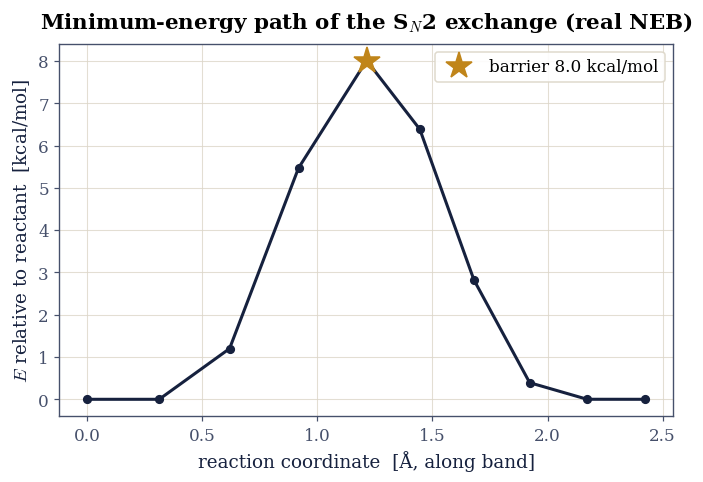

activation barrier = 8.01 kcal/mol; transition state at image 4 of 9


In [5]:
# (solution hidden on the public site)


### Validation 2 — a central barrier on a thermoneutral path

The chloride exchange is thermoneutral (reactant and product are mirror images), so
the endpoints must come out at equal energy, with a positive barrier of the right
size (several kcal/mol) peaked near the middle of the band. The path is only
approximately symmetric: the discrete images cluster unevenly around the transition
state.

In [6]:
validate.check(
    3 < barrier < 15 and thermoneutral < 0.5 and i_ts in (3, 4, 5, 6),
    "the path is thermoneutral with a central barrier of the right size",
    f"barrier {barrier:.1f} kcal/mol at image {i_ts}; endpoint energy difference {thermoneutral:.3f} kcal/mol",
)

✓  the path is thermoneutral with a central barrier of the right size   [barrier 8.0 kcal/mol at image 4; endpoint energy difference 0.000 kcal/mol]


True

## Exercise 3 — Convergence of the band

The band does not start on the minimum-energy path; it relaxes onto it. Each row of
the `.ener` file is one optimisation step, so plotting the barrier (the highest image,
relative to the endpoints) against step shows the band settling. It starts from the
linear interpolation between the endpoints, which cuts the corner and underestimates
the barrier, and climbs as the chain finds the true ridge, converging after a few tens
of iterations.

**Part a)** Compute the barrier at every optimisation step. **Part b)** Confirm it has
converged by the final steps.

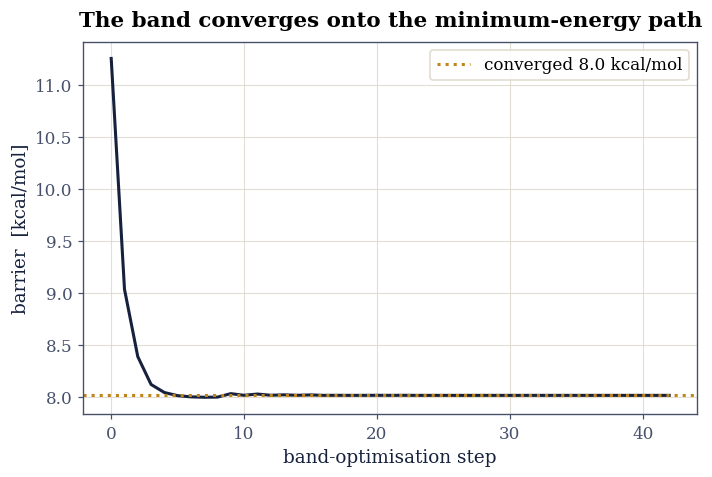

In [7]:
# (solution hidden on the public site)


### Validation 3 — the band has converged

By the final iterations the barrier must have stopped changing: the last few steps
should agree to a small fraction of a kcal/mol.

In [8]:
validate.check(
    drift < 0.2,
    "the NEB barrier has converged over the last few steps",
    f"change over the final 5 steps = {drift:.3f} kcal/mol (converged at {barrier_history[-1]:.2f})",
)

✓  the NEB barrier has converged over the last few steps   [change over the final 5 steps = 0.000 kcal/mol (converged at 8.01)]


True

## Notebook summary

We traced the minimum-energy path of the symmetric S$_N$2 chloride exchange with
the nudged elastic band, reading the course's committed band energies. The
converged path is a single barrier on a thermoneutral profile, with the
trigonal-bipyramidal transition state about $8\,$kcal/mol above the reactant, and
following the barrier over the band optimisation showed it climbing from the
corner-cutting linear interpolation onto the true ridge. The endpoints fix the
chemistry; the band finds the route between them.

## Outlook

- **The climbing image.** A climbing-image NEB drives the highest replica exactly to
  the saddle point, giving the barrier without interpolating between images.
- **Free energy, not energy.** The course continued to a *free*-energy surface from
  metadynamics (next notebook); the energetic barrier here is its zero-temperature
  limit.
- **Solvent.** The gas-phase Sₙ2 has a double-well shape with a small central barrier;
  in water the ion-dipole wells largely vanish and the barrier rises sharply, the
  classic solvent effect on Sₙ2 kinetics.
- **Endpoint quality.** A NEB is only as good as its endpoints; both must be true
  minima, which is why the exercise optimised them first.

### References

```{bibliography}
:filter: docname in docnames
```

In [9]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>